In [2]:
from kagglehub import dataset_download
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This returns the local folder where the dataset is stored
path = dataset_download("adrianmcmahon/imdb-india-movies")

print(path)

C:\Users\deepthi\.cache\kagglehub\datasets\adrianmcmahon\imdb-india-movies\versions\1


In [3]:
df = pd.read_csv(
    os.path.join(path, "IMDb Movies India.csv"),
    encoding="latin1"
)

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
# Shape of the dataset
df.shape

(15509, 10)

In [5]:
# First 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [7]:
# Statistical summary
df.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [8]:
# Missing values
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [9]:
# Duplicate rows
df.duplicated().sum()

6

In [10]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

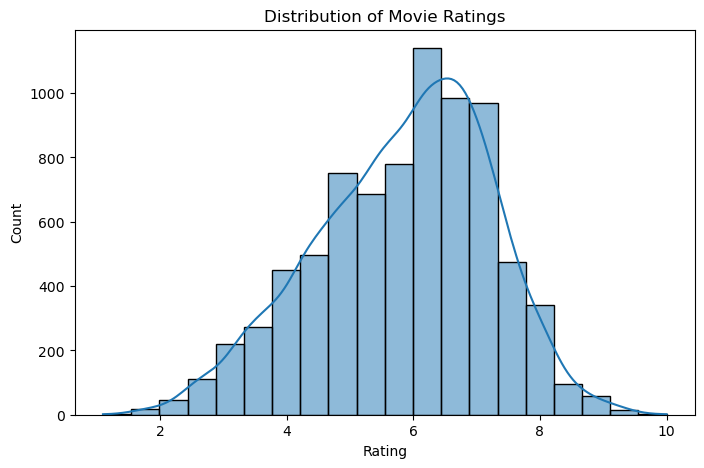

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.savefig(r"C:/Users/deepthi/OneDrive/Desktop/Movie Rating Prediction/images/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

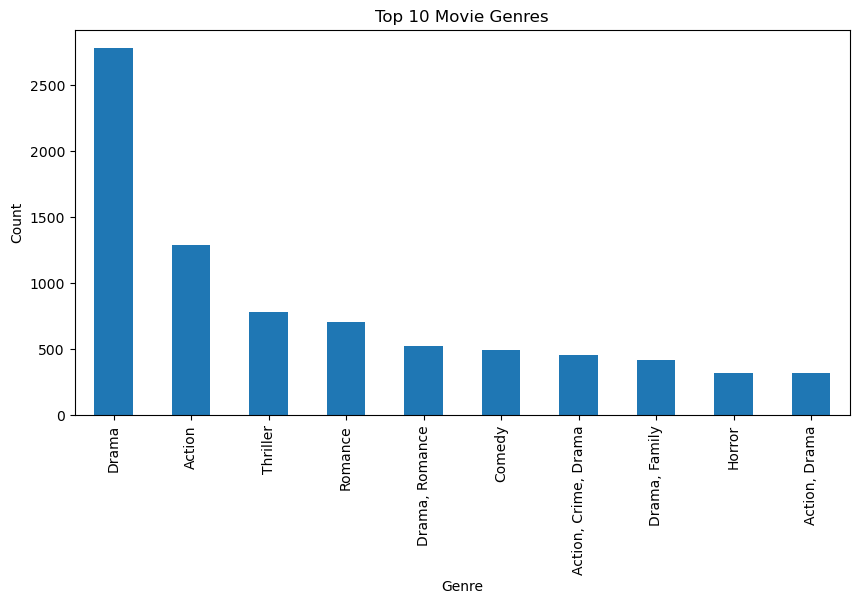

In [12]:
plt.figure(figsize=(10,5))

df["Genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres")
plt.ylabel("Count")
plt.savefig(r"C:/Users/deepthi/OneDrive/Desktop/Movie Rating Prediction/images/top_genres.png", dpi=300, bbox_inches="tight")
plt.show()

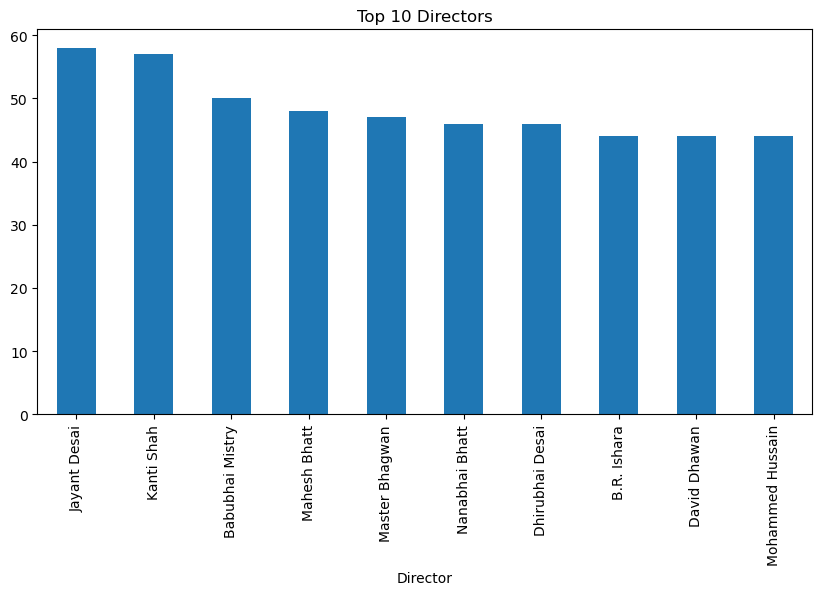

In [13]:
plt.figure(figsize=(10,5))

df["Director"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Directors")

plt.savefig(r"C:/Users/deepthi/OneDrive/Desktop/Movie Rating Prediction/images/top_directors.png", dpi=300, bbox_inches="tight")

plt.show()

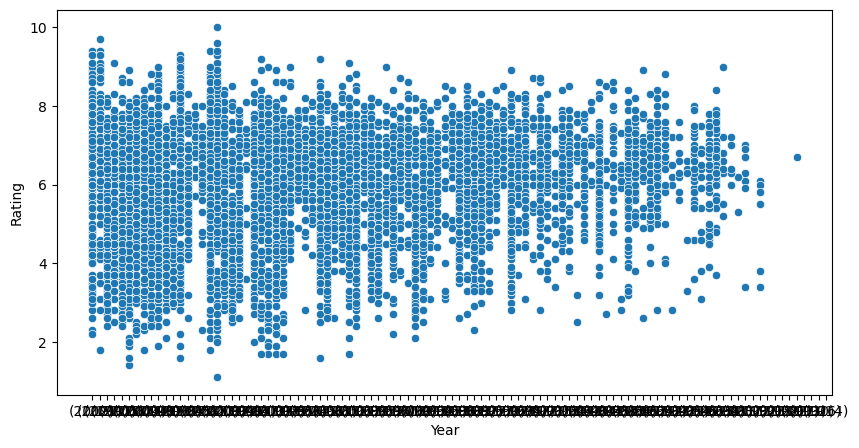

In [14]:
plt.figure(figsize=(10,5))

sns.scatterplot(x="Year", y="Rating", data=df)

plt.show()

In [15]:
temp = df.copy()

temp["Year"] = temp["Year"].str.extract("(\d+)")

temp["Duration"] = temp["Duration"].str.replace(" min","", regex=False)

temp["Votes"] = temp["Votes"].str.replace(",","", regex=False)

temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

temp["Duration"] = pd.to_numeric(temp["Duration"], errors="coerce")

temp["Votes"] = pd.to_numeric(temp["Votes"], errors="coerce")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\deepthi\AppData\Local\Temp\ipykernel_17648\3925517894.py:3: SyntaxWarning: invalid escape sequence '\d'
  temp["Year"] = temp["Year"].str.extract("(\d+)")


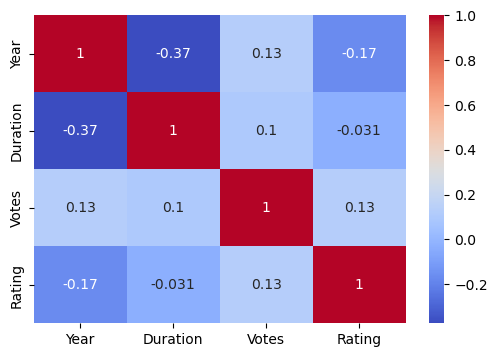

In [16]:
plt.figure(figsize=(6,4))

sns.heatmap(
    temp[["Year","Duration","Votes","Rating"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.savefig(r"C:/Users/deepthi/OneDrive/Desktop/Movie Rating Prediction/images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [18]:
df = df.dropna(subset=['Rating'])

In [19]:
df['Rating'].isnull().sum()

0

In [20]:
(2019)

2019

In [21]:
df['Year'] = df['Year'].str.extract('(\d{4})')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\deepthi\AppData\Local\Temp\ipykernel_17648\3546255144.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d{4})')


In [22]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [23]:
df['Year'].head()

1    2019
3    2019
5    1997
6    2005
8    2012
Name: Year, dtype: int64

In [24]:
df['Duration'] = df['Duration'].str.replace(' min','', regex=False)

In [25]:
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [26]:
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)

In [27]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   float64
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 680.5+ KB


In [29]:
numeric_cols = ['Year', 'Duration', 'Votes']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\deepthi\AppData\Local\Temp\ipykernel_17648\1413296333.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [30]:
categorical_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\deepthi\AppData\Local\Temp\ipykernel_17648\1921226325.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [31]:
df.duplicated().sum()

0

In [32]:
df = df.drop_duplicates()

In [33]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [34]:
X = df[['Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3',
        'Year',
        'Duration',
        'Votes']]

In [35]:
y = df['Rating']

In [36]:
numerical_features = [
    'Year',
    'Duration',
    'Votes'
]

categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [39]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [40]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [42]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Year', 'Duration',
                                                   'Votes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('model', LinearRegression())])

In [43]:
linear_predictions = linear_pipeline.predict(X_test)

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [45]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Year', 'Duration',
                                                   'Votes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [46]:
rf_predictions = rf_pipeline.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [48]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R² :", linear_r2)

Linear Regression
MAE : 0.9446795819674491
RMSE: 1.2060751558656806
R² : 0.21758810014494212


In [49]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

Random Forest
MAE : 0.800313131313131
RMSE: 1.078027415214727
R² : 0.37490458246154


In [50]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2 Score': [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.944680,1.206075,0.217588
1,Random Forest,0.800313,1.078027,0.374905


In [51]:
new_movie = pd.DataFrame({
    'Genre': ['Action'],
    'Director': ['S. S. Rajamouli'],
    'Actor 1': ['Prabhas'],
    'Actor 2': ['Rana Daggubati'],
    'Actor 3': ['Anushka Shetty'],
    'Year': [2017],
    'Duration': [167],
    'Votes': [150000]
})

predicted_rating = rf_pipeline.predict(new_movie)

print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 8.106500000000006
